# Requirements

This notebook uses the following third-party packages:

- opencv-python
- numpy
- matplotlib

Standard library modules used here:

- csv
- os

In [36]:
%pip install opencv-python numpy matplotlib

Looking in indexes: https://pypi.org/simple, https://www.piwheels.org/simple
Note: you may need to restart the kernel to use updated packages.


In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import csv
import os

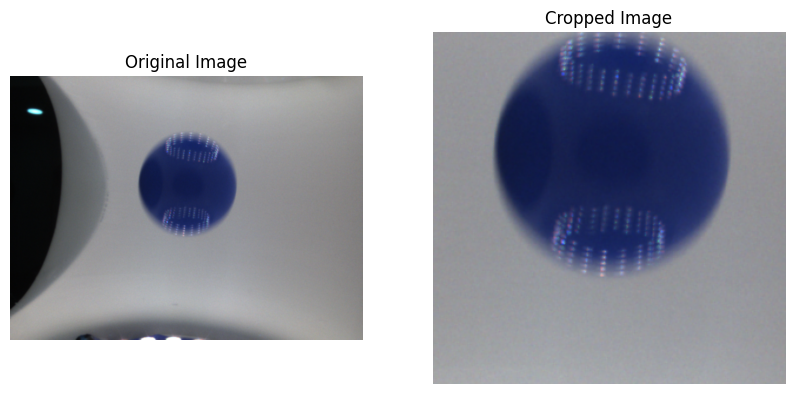

In [38]:

image_path = "out/frame_0001.png" 
csv_filename = "marble_dataset.csv"
visualize = True

# --- 1. Load Image ---
# In production, you will likely pass the frame directly from cap.read() 
# instead of reading from the disk to save heavy I/O time.
frame_bgr = cv2.imread(image_path)

if frame_bgr is None:
    print(f"Error: Could not load image at {image_path}")
    exit()

height, width = frame_bgr.shape[:2]

# --- 2. Fast Cropping ---
crop_w, crop_h = 300, 300
start_x = width // 2 - crop_w // 2
start_y = height // 2 - crop_h // 2

# Slicing the numpy array is an extremely fast O(1) operation
center_crop = frame_bgr[start_y:start_y+crop_h, start_x:start_x+crop_w]

# show old image and new image side by side
if visualize:
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Cropped Image")
    plt.imshow(cv2.cvtColor(center_crop, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.show()




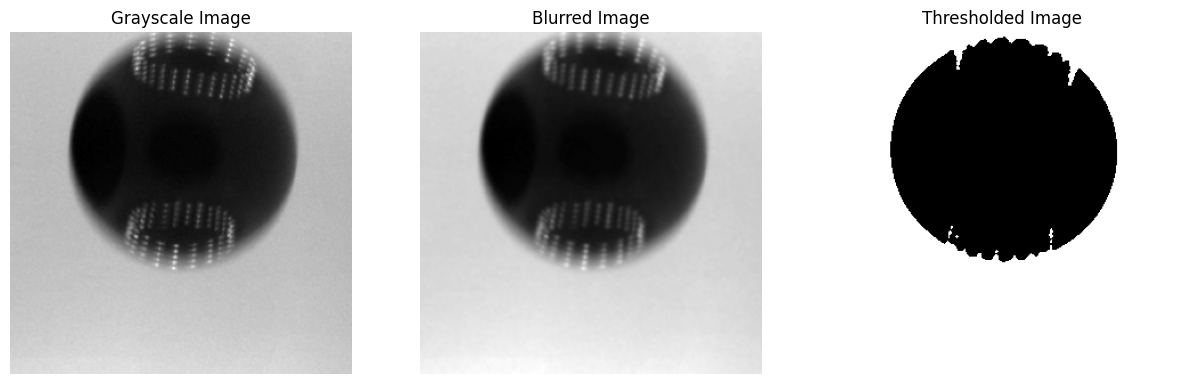

In [39]:
# --- 3. Optimized Processing ---
# Convert ONLY the small 300x300 crop to Grayscale (faster than converting the whole image)
frame_gray = cv2.cvtColor(center_crop, cv2.COLOR_BGR2GRAY)

# Reduced blur kernel from (9,9) to (5,5) for speed. Adjust if noise is too high.
blurred = cv2.GaussianBlur(frame_gray, (5, 5), 0)

# Thresholding
_, thresh = cv2.threshold(blurred, 100, 255, cv2.THRESH_BINARY)

# visualize the frame_gray, blurred and thresholded image
if visualize:
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title("Grayscale Image")
    plt.imshow(frame_gray, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Blurred Image")
    plt.imshow(blurred, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Thresholded Image")
    plt.imshow(thresh, cmap='gray')
    plt.axis('off')
    plt.show()

Total contours found: 1


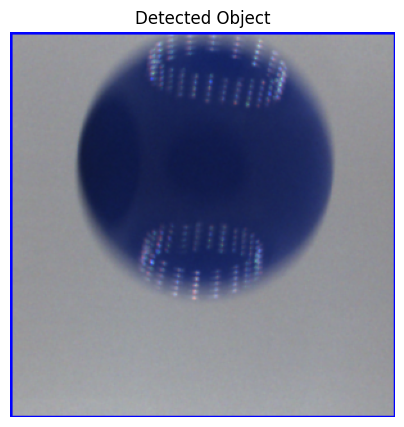

In [40]:
# --- 4. Contour Detection ---
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print(f"Total contours found: {len(contours)}")

# Initialize coordinates in case nothing is found
x, y, w, h = 0, 0, 0, 0
found_object = False
contour_area = 0

if contours:
    # Filter contours based on area roughly matching previous BlobDetector params
    valid_contours = [c for c in contours if 2000 <= cv2.contourArea(c) <= 100000]
    
    if valid_contours:
        # Grab the largest contour by area
        largest_contour = max(valid_contours, key=cv2.contourArea)
        contour_area = cv2.contourArea(largest_contour)
        x, y, w, h = cv2.boundingRect(largest_contour)
        found_object = True

# visualize the detected object on the cropped image
if visualize:
    output_image = center_crop.copy()
    if found_object:
        cv2.rectangle(output_image, (x, y), (x + w, y + h), (255, 0, 0), 2)

    plt.figure(figsize=(5, 5))
    plt.title("Detected Object")
    plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()


Result: Object found at Center=(150, 150), Area=89401.0


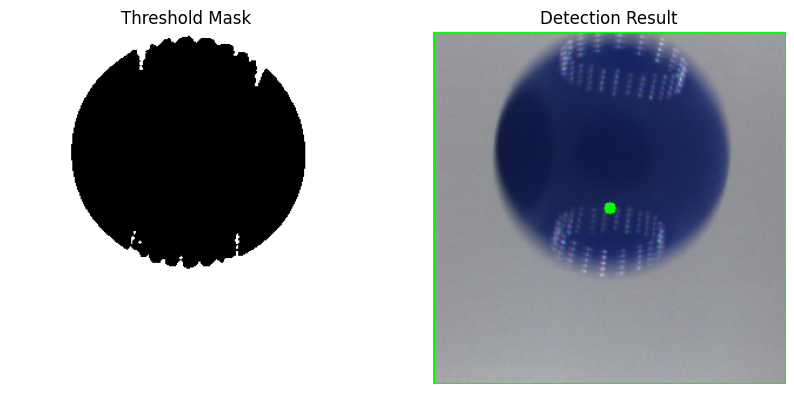

In [41]:
# --- 5. Save Data to CSV ---
# Open CSV in 'append' mode so we add a new row for each frame
file_exists = os.path.isfile(csv_filename)
with open(csv_filename, mode='a', newline='') as file:
    writer = csv.writer(file)
    
    # Write headers if the file is brand new
    if not file_exists:
        writer.writerow(['filename', 'x', 'y', 'width', 'height', 'object_found'])
        
    # Note: These x,y coordinates are relative to the 300x300 cropped image!
    writer.writerow([os.path.basename(image_path), x, y, w, h, found_object])

# --- 6. Visualization (Only runs when testing) ---
if visualize:
    # Convert BGR crop to RGB for matplotlib
    frame_rgb = cv2.cvtColor(center_crop, cv2.COLOR_BGR2RGB)
    output_img = frame_rgb.copy()
    
    if found_object:
        # Draw the bounding box
        cv2.rectangle(output_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
        
        # Draw the center point
        cx, cy = int(x + (w / 2)), int(y + (h / 2))
        cv2.circle(output_img, (cx, cy), 5, (0, 255, 0), -1)
        print(f"Result: Object found at Center=({cx}, {cy}), Area={contour_area}")
    else:
        print("Result: No object found matching criteria.")

    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    ax1.imshow(thresh, cmap='gray')
    ax1.set_title("Threshold Mask")
    ax1.axis('off')

    ax2.imshow(output_img)
    ax2.set_title("Detection Result")
    ax2.axis('off')
    plt.show()
